# Baseline: target = локальный минимум ±10

Все четыре индикатора оцениваются относительно локального минимума на горизонте 10 свежих публикаций ЦБ.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from fx_signal.baseline import build_baseline_frame

sns.set_theme(style='whitegrid')
HORIZON = 10
CONFIG = Path('../configs/baseline.yaml') if Path.cwd().name == 'notebooks' else Path('configs/baseline.yaml')
frame, metrics = build_baseline_frame(CONFIG, horizon=HORIZON)

## Покрытие и prevalence target

In [2]:
target_col = f'target_local_min_h{HORIZON}'
frame.groupby('currency')[target_col].agg(eligible='count', positives='sum', prevalence='mean')

,eligible,positives,prevalence
currency,,,
AMD,1868,59,0.031585
KGS,1868,58,0.031049
KZT,1868,64,0.034261
TJS,1868,57,0.030514
UZS,1868,58,0.031049


## Hit rate и lift каждого индикатора

In [3]:
metrics.sort_values(['corridor', 'lift'], ascending=[True, False]).reset_index(drop=True)

,horizon,corridor,indicator,eligible_days,signal_count,target_positives,signal_hit_rate,random_hit_rate,lift,signals_per_week
0,10,RUB->AMD,momentum,1789,251,56,0.139442,0.031302,4.454681,0.664272
1,10,RUB->AMD,level,1789,302,56,0.089404,0.031302,2.856138,0.799244
2,10,RUB->AMD,seasonality,1789,356,56,0.030899,0.031302,0.987109,0.942155
3,10,RUB->AMD,reversal,1789,87,56,0.000000,0.031302,0.000000,0.230246
4,10,RUB->KGS,momentum,1789,272,54,0.099265,0.030184,3.288603,0.719849
5,10,RUB->KGS,level,1789,361,54,0.085873,0.030184,2.844927,0.955388
6,10,RUB->KGS,seasonality,1789,382,54,0.028796,0.030184,0.953995,1.010964
7,10,RUB->KGS,reversal,1789,98,54,0.000000,0.030184,0.000000,0.259357
8,10,RUB->KZT,momentum,1789,249,60,0.120482,0.033538,3.592369,0.658979
9,10,RUB->KZT,level,1789,379,60,0.068602,0.033538,2.045471,1.003025


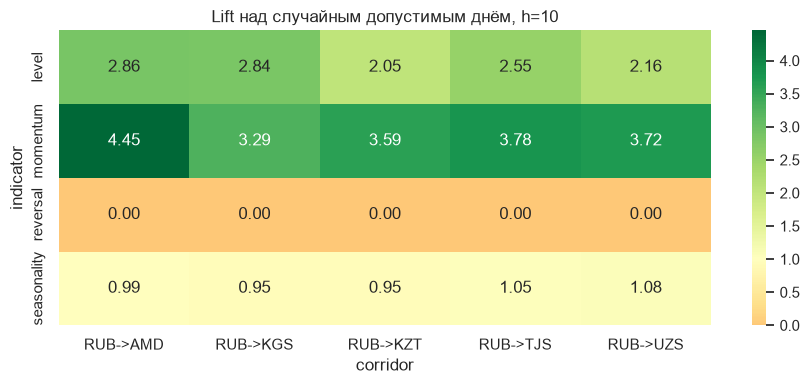

In [4]:
heatmap = metrics.pivot(index='indicator', columns='corridor', values='lift')
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heatmap, annot=True, fmt='.2f', center=1.0, cmap='RdYlGn', ax=ax)
ax.set_title(f'Lift над случайным допустимым днём, h={HORIZON}')
fig.tight_layout()
repo_root = CONFIG.resolve().parent.parent
figures_dir = repo_root / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / f'baseline_lift_h{HORIZON}.png', dpi=160, bbox_inches='tight')

## Интерпретация

lift > 1 означает, что правило чаще случайного допустимого дня совпадает с выбранным local-min target. Reversal срабатывает после минимума, поэтому его низкий lift здесь нельзя считать окончательным выводом о полезности: для него нужна отдельная метрика последующего роста курса.